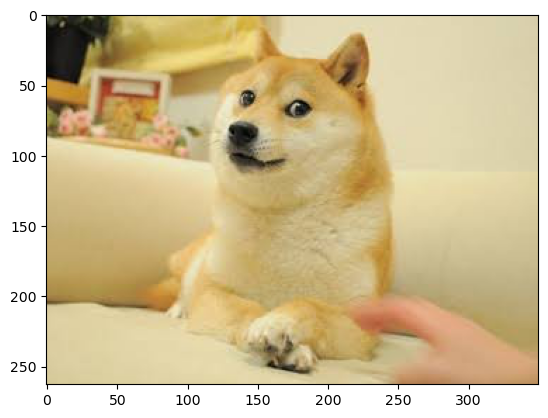

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("Dog.jpg")
glass = cv2.imread("1.png", cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)

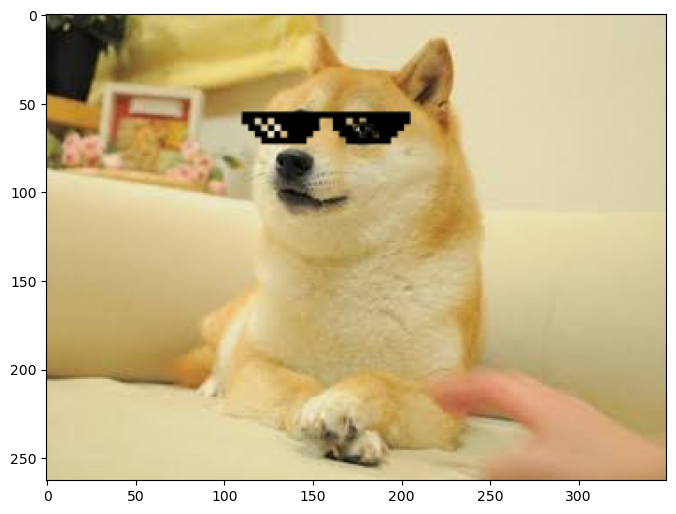

In [6]:
x = 105
y = 30
width = 110
height = int(glass.shape[0] * width / glass.shape[1])

glass = cv2.resize(glass, (width, height), interpolation=cv2.INTER_AREA)

roi = image[y:y+height, x:x+width]

alpha = glass[:, :, 3].astype(float) / 255
alpha = np.repeat(alpha[:, :, np.newaxis], 3, axis=2)

glass_rgb = cv2.cvtColor(glass[:, :, :3], cv2.COLOR_BGR2RGB)

blended = glass_rgb * alpha + roi * (1 - alpha)

result = image.copy()
result[y:y+height, x:x+width] = np.clip(blended, 0, 255).astype(np.uint8)

cv2.imwrite("baby_sunglasses.jpg", cv2.cvtColor(result, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(8, 8))
plt.imshow(result)
plt.show()
